In [1]:
from collections import Counter
import cirq
from cirq.contrib.svg import SVGCircuit
import warnings
import sys
import matplotlib.pyplot as plt

sys.path.append("../")
import resource_estimation as res
import scripts.layout_figures as lfs


warnings.filterwarnings("ignore", category=UserWarning)
_COLORS = {
    "None": "#ffffff",
    "T Factory": "#4ddef1",
    "S Factory": "#fcc084",
    "Data Qubit": "#a4f0c2",
    "Ancilla Patch": "#f5bad6",
    "Distillation": "#E6E6FA",
    "CNOT": "#ed6340",
    "Toff Factory": "#000000",
}
_PRETTY = False  # I don't think the SVG circuits are pretty, but this is an option
cast_circuit = lambda circuit: SVGCircuit(circuit) if _PRETTY else circuit  # A cirq contribution's version of 'pretty'

# Overview
This notebook shows how to use `resource-superstaq` to estimate quantum resources for a circuit expressed in terms of T, S, CNOT, H, and TOFFOLI gates, using T-state and CCZ-state distillation.  That is, the circuit has already been cast in terms of Clifford+T+Toffoli.   Currently, only Movement Architectures and the `MovementDistillery` layout support distillation.  The key metrics will be physical qubits, circuit runtime, and physical operation count. The basic flow is shown below:
- Have a `cirq` circuit
- Choose a Movement Architecture
    - Single Species with Movement (`DefaultMovement`) (SSM)
    - Dual Species with Movement (DSM)
- Use the Distillation Layout
    - Use `MovementDistillery` for SSM or DSM
- Compile Clifford + T + Toffoli circuit to Primitives
    -  Primitives are Gate-like objects with simple physical decompositions
    -  This step includes operations for movement for movement-based architectures
- Estimate Resources
    - Count gates by unrolling gate costs for primitives
    - Extract time by unrolling gate times for primitives


## Have a Circuit
For this example, we use a random unitary

In [2]:
qubits = 5
def make_test_circuit(num_qubits) -> cirq.Circuit:
    circuit = cirq.testing.random_circuit(
        cirq.LineQubit.range(num_qubits),
        10,
        0.6,
        {cirq.T: 1, cirq.S: 1, cirq.CNOT: 2, cirq.H: 1, cirq.TOFFOLI: 3},
        44,
    )
    return circuit
circuit = make_test_circuit(qubits)
cast_circuit(circuit) # This circuit is only composed of Cliffords, Ts, and Toffolis

┌──┐
0: ───────@───H─────────────────────────@────@───
          │                             │    │
1: ───────@───────────T───────H─────────┼────X───
          │                             │    │
2: ───────X───────S─────────────────────┼────┼───
                                        │    │
3: ───────────────────H────────────────T┼────@───
                                        │
4: ───────────H───────────────H───S─────X────────
                                      └──┘

## Choose a Movement Architecture

In [3]:
ssm = res.ftqc.DefaultMovement(
    d=11,  # Rotated Surface Code code distance
    idling=False,  # Include Syndrome Extraction on idling qubits in compiled circuit
    post_op_correction=True,  # Turn on or off Syndrome Extraction after transversal operations
    syndrome_rounds=1,  # Rounds of Syndrome Extraction after transversal operations
    cultivation_repetition=5,  # Expected repetitions of the cultivation circuit to get a successful T state
    distillation_repetition=1, # Expected repetitions of the distillation circuits to get a successful T and Toffoli state
)
estimator = res.ftqc.ResourceEstimator(arc=ssm) # Create an estimator object
# Notice the T-states used as input for distillation come from cultivation

## Choose a Layout

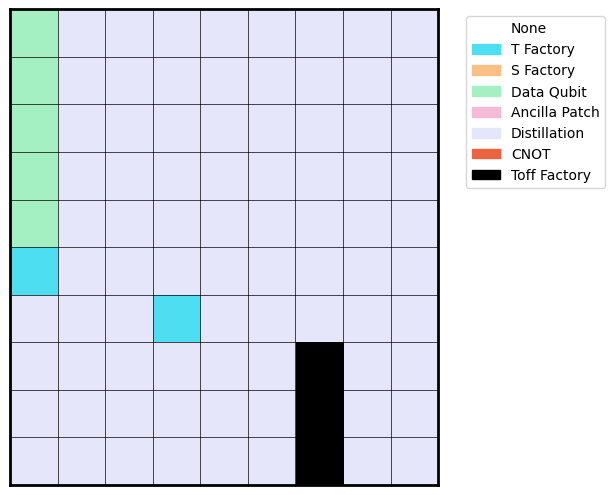

In [4]:
layout = res.ftqc.layout.MovementDistillery(input_circuit=circuit, num_t_factories=2, num_toff_factories=1)
fig, ax, im = lfs.plot_layout(layout, category_colors=_COLORS, transpose=True)

## FT Compile

In [5]:
# Recompile the circuit in terms of primitives
primitive_circuit = res.ftqc.ft_compile(layout=layout, arc=ssm, verbose=True)
cast_circuit(primitive_circuit)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 68947.46it/s]


┌────┐                                                                                                                                                                                                                                 ┌───┐
(0, 0): ───SE(1)─────────────────────────────MOVE_IZ─────X──────MOVE_IZ───SE(1)───#2────────────────────────────────────────H───────────────────────────SE(1)───MOVE_IZ───@───────MOVE_IZ───SE(1)───────────────────────────────────────────────────────────────────────────────────MOVE_IZ────X──────MOVE_IZ───SE(1)───ERROR CORRECT─────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                         │                        │                                                                                       │                                                                                                                    │                        │
(0, 1): ───SE(1)─────────────────────────────MOVE_IZ────X┼──────MOVE_IZ───SE(1)───ERROR CORRECT─────────────────────────────MOVE_IZ───X───────MOVE_IZ───SE(1)───S─────────┼─────────────────SE(1)───H───────────────────────────SE(1)───────────────────────────────────────────────MOVE_IZ────┼─X────MOVE_IZ───SE(1)───#3────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                        ││                        │                                                   │                                   │                                                                                                                    │ │                      │
(0, 2): ───SE(1)─────────────────────────────MOVE_IZ────┼┼X─────MOVE_IZ───SE(1)───#3────────────────────────────────────────S─────────┼─────────────────SE(1)─────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─┼──────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                        │││                                                                           │                                   │                                                                                                                    │ │                      │
(0, 3): ───SE(1)───H─────────────────SE(1)───MOVE_IZ────┼┼┼X────MOVE_IZ───SE(1)───S─────────────────────────────────SE(1)─────────────┼───────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────MOVE_IZ────┼X┼────MOVE_IZ───SE(1)───#2────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                        ││││                                                                          │                                   │                                                                                                                    │││
(0, 4): ───SE(1)───H─────────────────SE(1)───H──────────┼┼┼┼──────────────SE(1)───S─────────────────────────────────SE(1)─────────────┼─────────────────────────MOVE_IZ───X───────MOVE_IZ───SE(1)──────────────────────────────────────────────────────────────────────────────────────────────┼┼┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                        ││││                                                                          │                                                                                                                                                        │││
(0, 5): ───────────#31──────────────────────────────────┼┼┼┼────────────────────────

In [6]:
# Primitive gate counts
primitive_gate_counts = Counter(['Measure' if op in cirq.GateFamily(cirq.MeasurementGate) else str(op.gate) for op in primitive_circuit.all_operations()])
print("Primitive gate counts")
for op, count in sorted(primitive_gate_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")

Primitive gate counts
SE(1)                    40
MOVE_IZ                  36
MOVE_MZ                  16
CNOT                     9
Measure                  8
reset                    8
H                        5
S                        4
DISTIL(Toffoli)          2
DISTIL(T)                2
ERROR CORRECT            2


In [7]:
# Primitives in the critical path
primitive_cost = estimator.critical_path(primitive_circuit)
primitive_counts = Counter(['Measure' if primitive in cirq.GateFamily(cirq.MeasurementGate) else str(primitive.gate) for primitive in primitive_cost])
print("Critical path primitives")
for op, count in sorted(primitive_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")

Critical path primitives
MOVE_IZ                  4
SE(1)                    4
MOVE_MZ                  4
DISTIL(Toffoli)          2
CNOT                     2
Measure                  2
reset                    2


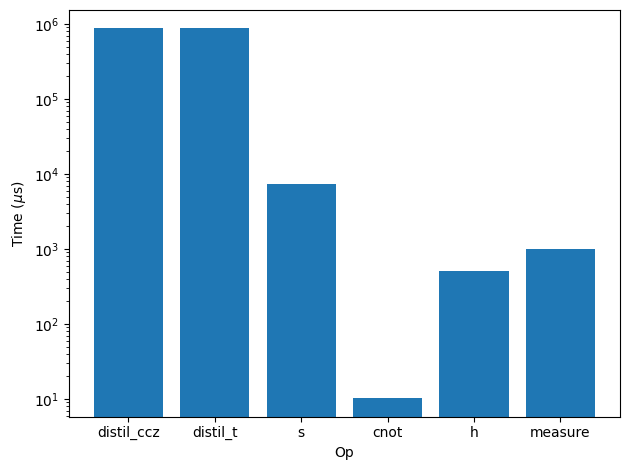

In [8]:
# We see distil_t is the largest cost in time
op_times = [ssm._distil_cost("Toffoli")["op_time"], 
 ssm._distil_cost("T")['op_time'],
 ssm._s_cost["op_time"],
 ssm._cnot_cost["op_time"],
 ssm._h_cost["op_time"],
 ssm._measure_cost["op_time"],
]
op_names = ['distil_ccz',
            'distil_t',
            's',
            'cnot',
            'h',
            'measure',]
f, ax = plt.subplots()
ax.bar(op_names, op_times)
ax.set_xlabel("Op")
ax.set_ylabel(r"Time ($\mu$s)")
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Estimate Resources

In [9]:
# Extract the various costs
gate_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit)
physical_qubits = estimator.physical_qubits(primitive_circuit)

In [10]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}\nQubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     96
PhasedXZGate             56
CZ                       38
ResetChannel             8
MeasurementGate          8
*********************************
Metrics
Time (μs)                1.77e+06
Qubits                   2.17e+04
*********************************
